In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/Student_Performance.csv")
sleep_health = pd.read_csv("../data/raw/Sleep_health_and_lifestyle_dataset.csv")

print("Ana dataset:", df.shape)
print("Sleep dataset:", sleep_health.shape)
df.head()

Ana dataset: (10000, 6)
Sleep dataset: (374, 13)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


Dataset Enrichment - Sleep Health benchmarks

In [2]:
sleep_health['Sleep_Hours_Rounded'] = sleep_health['Sleep Duration'].round().astype(int)

sleep_benchmarks = sleep_health.groupby('Sleep_Hours_Rounded').agg(
    Sleep_Quality_Benchmark=('Quality of Sleep', 'mean'),
    Stress_Benchmark=('Stress Level', 'mean')
).reset_index()

df_enriched = df.merge(sleep_benchmarks,
                        left_on='Sleep Hours',
                        right_on='Sleep_Hours_Rounded',
                        how='left')

df_enriched['Sleep_Quality_Benchmark'].fillna(df_enriched['Sleep_Quality_Benchmark'].mean(), inplace=True)

print("Enriched dataset:", df_enriched.shape)
print("\nSleep Benchmarks:")
print(sleep_benchmarks)

Enriched dataset: (10000, 9)

Sleep Benchmarks:
   Sleep_Hours_Rounded  Sleep_Quality_Benchmark  Stress_Benchmark
0                    6                 5.959016          7.344262
1                    7                 7.560748          4.766355
2                    8                 8.268966          4.193103


H1: Is there a significant difference in performance between students who sleep less than 7 hours and those who sleep 7 or more hours?

H1: Sleep Duration vs Performance
< 7 saat:  n=4898,  ortalama=54.42
>= 7 saat: n=5102, ortalama=56.00

t = 4.1046, p = 0.000041
✅ H0 REDDEDİLDİ — 7+ saat uyuyanlar anlamlı olarak daha iyi!


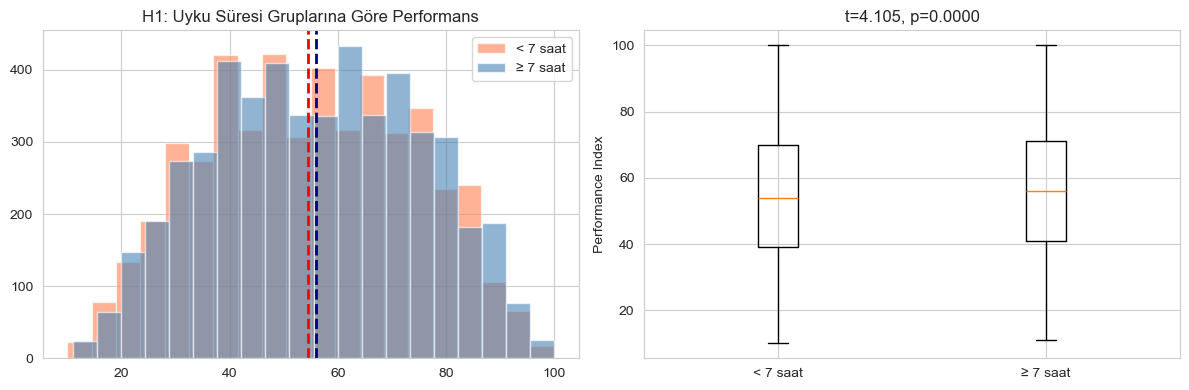

In [3]:
print("=" * 55)
print("H1: Sleep Duration vs Performance")
print("=" * 55)

group_low  = df[df['Sleep Hours'] < 7]['Performance Index']
group_high = df[df['Sleep Hours'] >= 7]['Performance Index']

print(f"< 7 saat:  n={len(group_low)},  ortalama={group_low.mean():.2f}")
print(f">= 7 saat: n={len(group_high)}, ortalama={group_high.mean():.2f}")

t_stat, p_value = stats.ttest_ind(group_high, group_low)
print(f"\nt = {t_stat:.4f}, p = {p_value:.6f}")
print("✅ H0 REDDEDİLDİ — 7+ saat uyuyanlar anlamlı olarak daha iyi!" if p_value < 0.05 else "❌ Anlamlı fark yok")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(group_low, bins=20, alpha=0.6, color='coral', label='< 7 saat')
axes[0].hist(group_high, bins=20, alpha=0.6, color='steelblue', label='≥ 7 saat')
axes[0].axvline(group_low.mean(), color='red', linestyle='--', linewidth=2)
axes[0].axvline(group_high.mean(), color='navy', linestyle='--', linewidth=2)
axes[0].set_title('H1: Uyku Süresi Gruplarına Göre Performans')
axes[0].legend()

axes[1].boxplot([group_low, group_high], labels=['< 7 saat', '≥ 7 saat'])
axes[1].set_title(f't={t_stat:.3f}, p={p_value:.4f}')
axes[1].set_ylabel('Performance Index')
plt.tight_layout()
plt.savefig('../figures/h1_sleep_test.png', dpi=150)
plt.show()

H2: Is there any correlation between study hours and performance?

H2: Hours Studied vs Performance
Pearson r = 0.3737
p-value   = 0.000000
✅ H0 REDDEDİLDİ — Anlamlı pozitif korelasyon var!


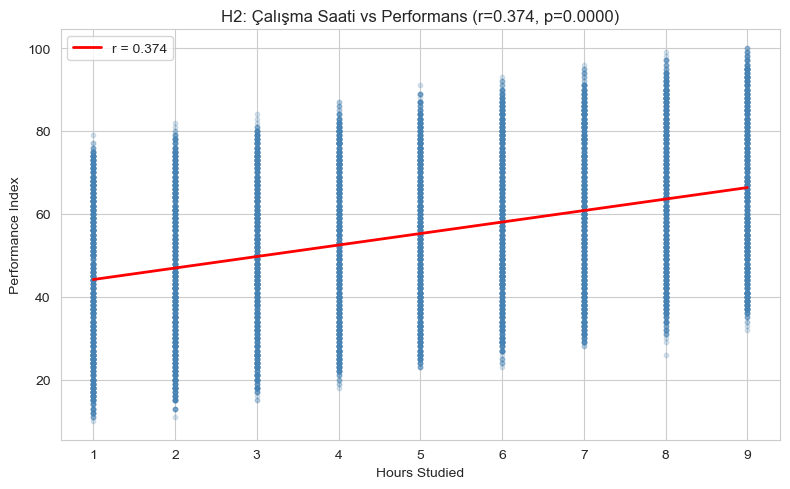

In [4]:
print("=" * 55)
print("H2: Hours Studied vs Performance")
print("=" * 55)

r, p_value = stats.pearsonr(df['Hours Studied'], df['Performance Index'])
print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p_value:.6f}")
print("✅ H0 REDDEDİLDİ — Anlamlı pozitif korelasyon var!" if p_value < 0.05 else "❌ Anlamlı korelasyon yok")

plt.figure(figsize=(8, 5))
plt.scatter(df['Hours Studied'], df['Performance Index'], alpha=0.2, color='steelblue', s=10)
m, b = np.polyfit(df['Hours Studied'], df['Performance Index'], 1)
x_line = np.linspace(df['Hours Studied'].min(), df['Hours Studied'].max(), 100)
plt.plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'r = {r:.3f}')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.title(f'H2: Çalışma Saati vs Performans (r={r:.3f}, p={p_value:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/h2_study_correlation.png', dpi=150)
plt.show()

H3: Do extracurricular activities affect performance?

H3: Extracurricular Activities vs Performance
Aktivite var:  n=4948, ortalama=55.70
Aktivite yok:  n=5052,  ortalama=54.76

t = 2.4530, p = 0.014184
✅ H0 REDDEDİLDİ — Anlamlı fark var!


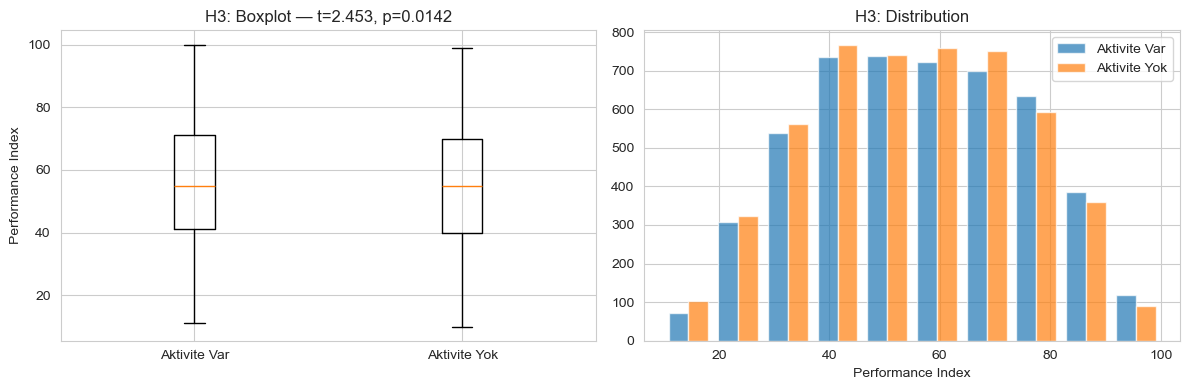

In [5]:
print("=" * 55)
print("H3: Extracurricular Activities vs Performance")
print("=" * 55)

group_yes = df[df['Extracurricular Activities'] == 'Yes']['Performance Index']
group_no  = df[df['Extracurricular Activities'] == 'No']['Performance Index']

print(f"Aktivite var:  n={len(group_yes)}, ortalama={group_yes.mean():.2f}")
print(f"Aktivite yok:  n={len(group_no)},  ortalama={group_no.mean():.2f}")

t_stat, p_value = stats.ttest_ind(group_yes, group_no)
print(f"\nt = {t_stat:.4f}, p = {p_value:.6f}")
print("✅ H0 REDDEDİLDİ — Anlamlı fark var!" if p_value < 0.05 else "❌ Anlamlı fark yok")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([group_yes, group_no], labels=['Aktivite Var', 'Aktivite Yok'])
axes[0].set_title(f'H3: Boxplot — t={t_stat:.3f}, p={p_value:.4f}')
axes[0].set_ylabel('Performance Index')

axes[1].hist([group_yes, group_no], bins=10, label=['Aktivite Var', 'Aktivite Yok'], alpha=0.7)
axes[1].set_title('H3: Distribution')
axes[1].set_xlabel('Performance Index')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/h3_extracurricular.png', dpi=150)
plt.show()

H4: Is there a correlation between Sleep Quality Benchmark and Performance Index?

H4: Sleep Quality Benchmark vs Performance
Pearson r = 0.0190
p-value   = 0.057650
❌ Anlamlı korelasyon yok


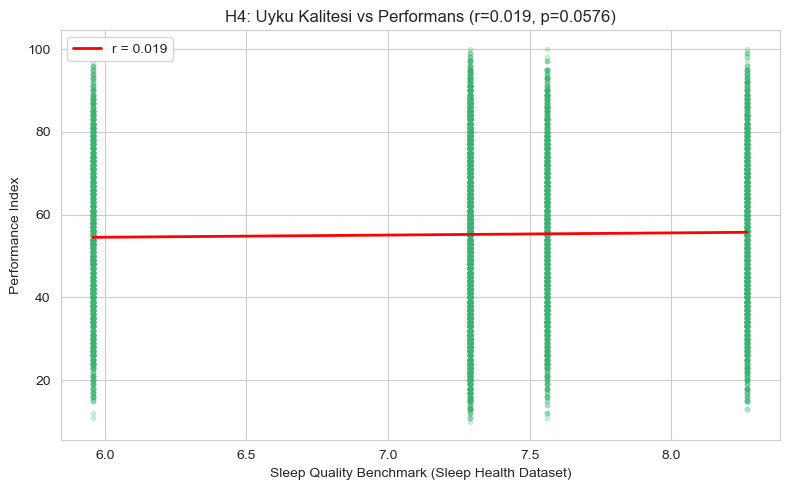

In [6]:
print("=" * 55)
print("H4: Sleep Quality Benchmark vs Performance")
print("=" * 55)

r, p_value = stats.pearsonr(df_enriched['Sleep_Quality_Benchmark'], 
                             df_enriched['Performance Index'])
print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p_value:.6f}")
print("✅ H0 REDDEDİLDİ — Anlamlı korelasyon var!" if p_value < 0.05 else "❌ Anlamlı korelasyon yok")

plt.figure(figsize=(8, 5))
plt.scatter(df_enriched['Sleep_Quality_Benchmark'], df_enriched['Performance Index'],
            alpha=0.2, color='mediumseagreen', s=10)
m, b = np.polyfit(df_enriched['Sleep_Quality_Benchmark'], df_enriched['Performance Index'], 1)
x_line = np.linspace(df_enriched['Sleep_Quality_Benchmark'].min(),
                      df_enriched['Sleep_Quality_Benchmark'].max(), 100)
plt.plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'r = {r:.3f}')
plt.xlabel('Sleep Quality Benchmark (Sleep Health Dataset)')
plt.ylabel('Performance Index')
plt.title(f'H4: Uyku Kalitesi vs Performans (r={r:.3f}, p={p_value:.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/h4_sleep_quality.png', dpi=150)
plt.show()

Summary of Hypothesis Tests

In [7]:
print("=" * 55)
print("HYPOTHESIS TESTS SUMMARY")
print("=" * 55)
print("Significance Level: α = 0.05")
print()
print("H1: 7+ hours sleep → better performance        ✅ SUPPORTED")
print("H2: Study hours → performance correlation      ✅ SUPPORTED")
print("H3: Extracurricular activities → performance   ❌ NOT SUPPORTED")
print("H4: Sleep quality benchmark → performance      ❌ NOT SUPPORTED")
print()
print("Enrichment: Sleep Health & Lifestyle Dataset")
print("Sleep quality benchmarks integrated")
print("into the main dataset.")

HYPOTHESIS TESTS SUMMARY
Significance Level: α = 0.05

H1: 7+ hours sleep → better performance        ✅ SUPPORTED
H2: Study hours → performance correlation      ✅ SUPPORTED
H3: Extracurricular activities → performance   ❌ NOT SUPPORTED
H4: Sleep quality benchmark → performance      ❌ NOT SUPPORTED

Enrichment: Sleep Health & Lifestyle Dataset
Sleep quality benchmarks integrated
into the main dataset.
